**PHASE 1: Setup & Exploration**

In [ ]:
# Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_selection import RFECV
from sklearn.decomposition import PCA

# Models
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (confusion_matrix, roc_auc_score, classification_report,
                             roc_curve, precision_recall_curve)

# Configuration
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries Loaded.")

Libraries Loaded.


In [ ]:
# Load the dataset
df = pd.read_csv('SMHS_dementia_students_final.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
print(df.columns.tolist())


Dataset shape: (2500, 31)

Column names:
['id', 'age', 'sex', 'socioeconomic_index', 'bmi', 'physical_activity_score', 'social_isolation_score', 'sleep_hours', 'gardening_hours', 'hypertension', 'diabetes', 'stroke_history', 'cvd_history', 'hearing_loss', 'frailty_index', 'depression_score', 'mmse_score', 'executive_function_z', 'memory_z', 'cognitive_reserve_index', 'hippocampal_volume', 'white_matter_lesion_volume', 'il6', 'crp', 'il10', 'nfl', 'shingles_vaccine', 'years_since_vaccination', 'gp_visits_last_year', 'visited_memory_clinic_last_year', 'dementia_dx']


Identified 29 numerical features:
['age', 'socioeconomic_index', 'bmi', 'physical_activity_score', 'social_isolation_score', 'sleep_hours', 'gardening_hours', 'hypertension', 'diabetes', 'stroke_history', 'cvd_history', 'hearing_loss', 'frailty_index', 'depression_score', 'mmse_score', 'executive_function_z', 'memory_z', 'cognitive_reserve_index', 'hippocampal_volume', 'white_matter_lesion_volume', 'il6', 'crp', 'il10', 'nfl', 'shingles_vaccine', 'years_since_vaccination', 'gp_visits_last_year', 'visited_memory_clinic_last_year', 'dementia_dx']


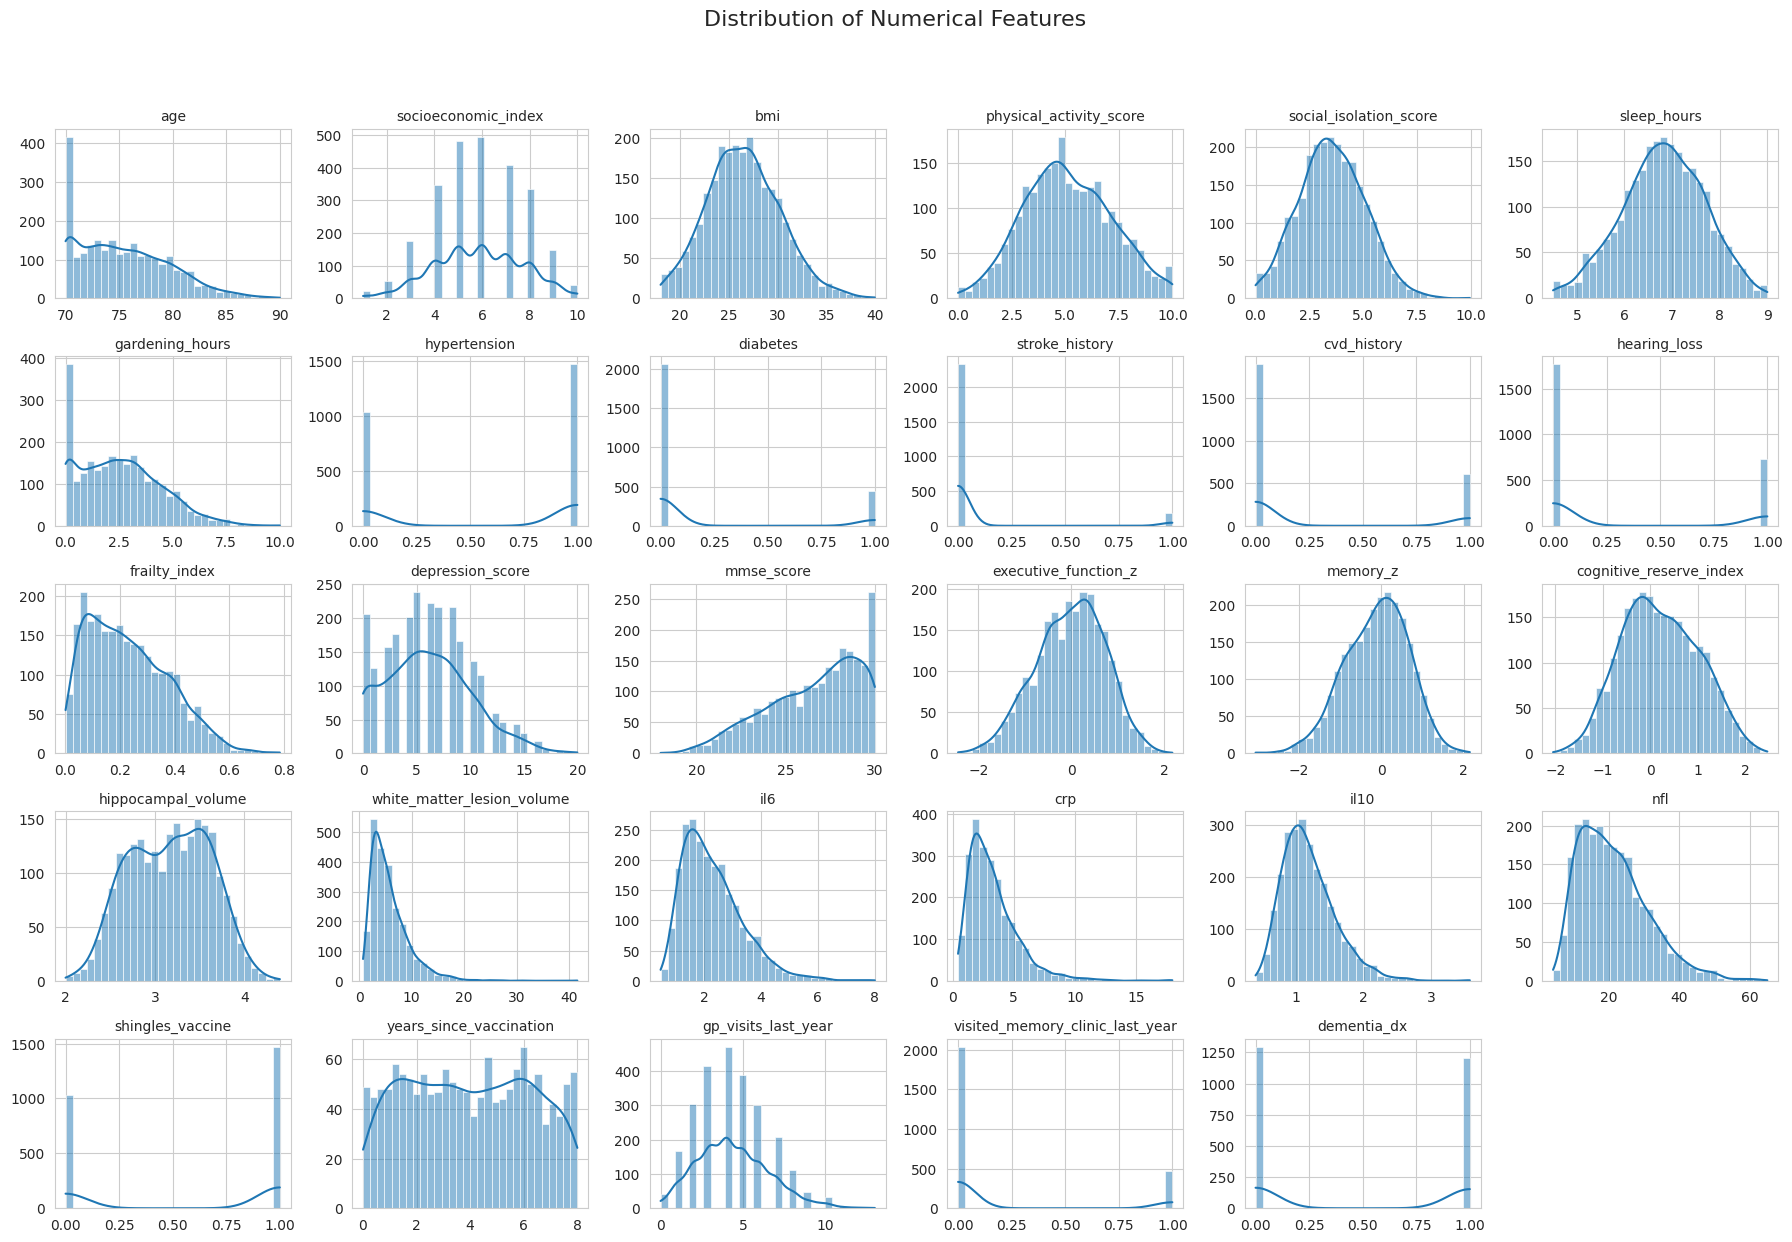

Generated histograms for all numerical features and saved to numerical_feature_distributions.png


In [ ]:
# Histograms

if 'id' in df.columns:
    df = df.drop(columns=['id'])
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
print(f'Identified {len(numerical_features)} numerical features:')
print(numerical_features)

num_features = len(numerical_features)
cols = 6
rows = int(np.ceil(num_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2.5))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribution of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
plt.savefig('numerical_feature_distributions.png', dpi=200, bbox_inches='tight')
plt.show()
print('Generated histograms for all numerical features and saved to numerical_feature_distributions.png')

Correlation Heatmap (Check for multicollinearity)

Correlation matrix calculated.


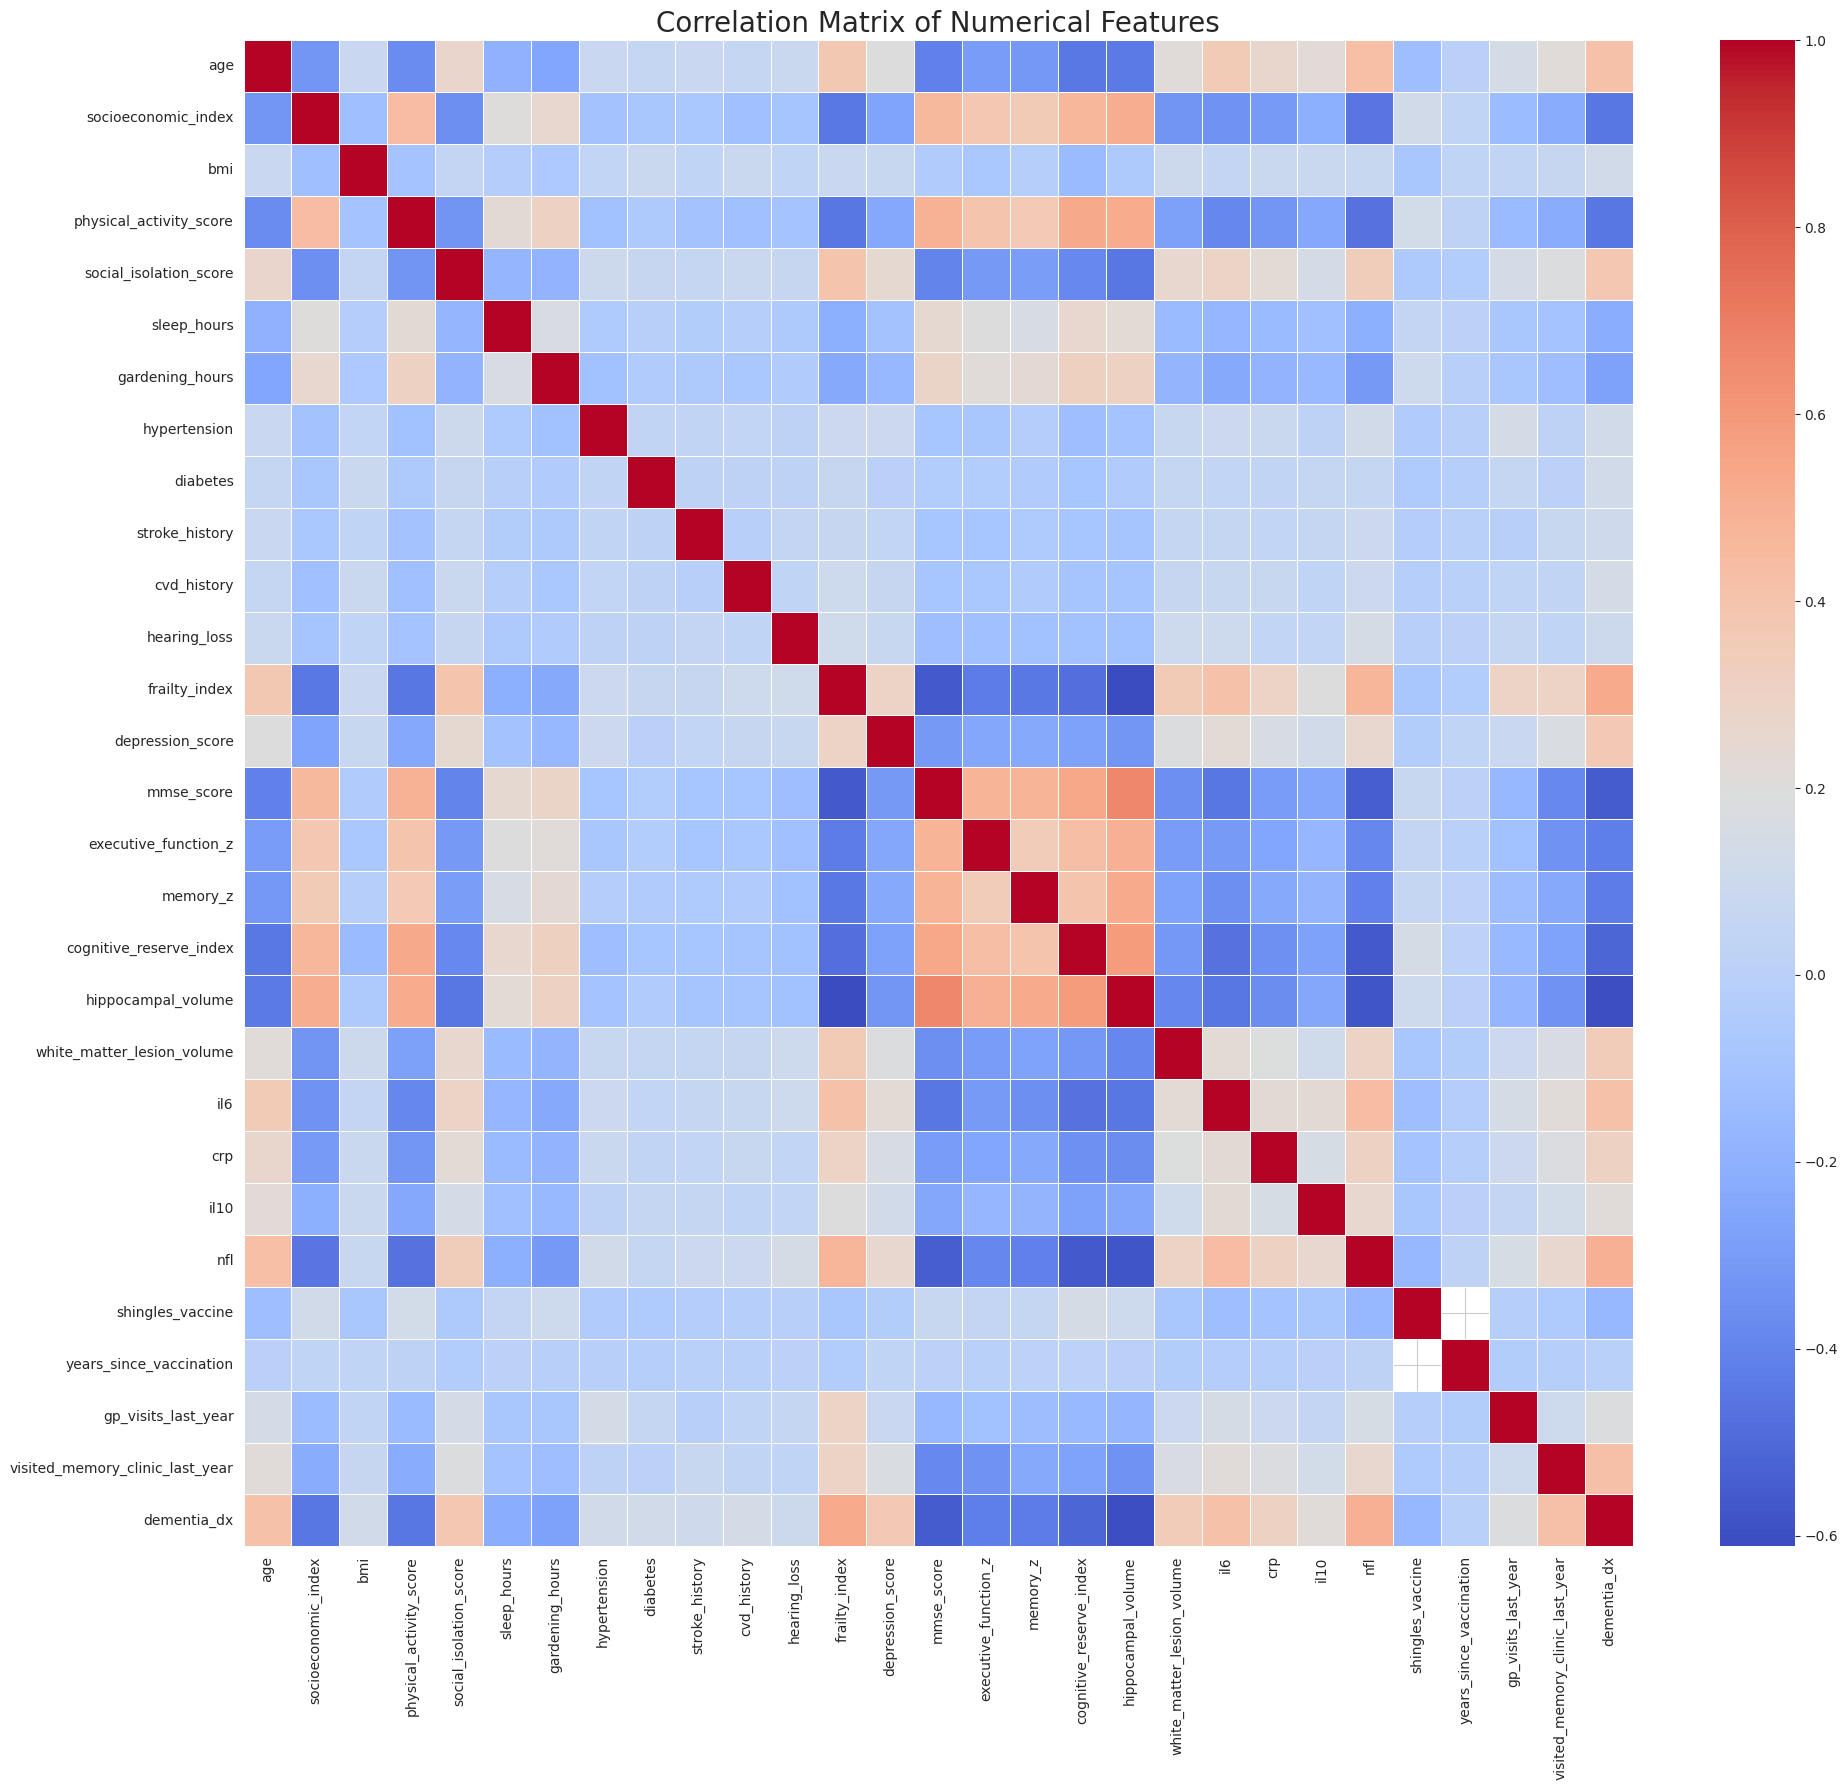

Generated feature correlation heatmap and saved to feature_correlation_heatmap.png


In [ ]:
correlation_matrix = df[numerical_features].corr()
print('Correlation matrix calculated.')

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=200)
plt.show()
print('Generated feature correlation heatmap and saved to feature_correlation_heatmap.png')

Phase 2: Clustering(Unsupervised Learning)

In [ ]:
# Select numeric biomedical features for clustering
# (biomarkers, frailty, cognition, imaging, vascular)
clustering_features = [
    'bmi', 'frailty_index', 'mmse_score', 'executive_function_z', 'memory_z',
    'cognitive_reserve_index', 'hippocampal_volume', 'white_matter_lesion_volume',
    'il6', 'crp', 'il10', 'nfl', 'depression_score'
]

print('Clustering features selected:')
print(clustering_features)
print(f'\nMissing values in clustering features:')
print(df[clustering_features].isnull().sum())

Clustering features selected:
['bmi', 'frailty_index', 'mmse_score', 'executive_function_z', 'memory_z', 'cognitive_reserve_index', 'hippocampal_volume', 'white_matter_lesion_volume', 'il6', 'crp', 'il10', 'nfl', 'depression_score']

Missing values in clustering features:
bmi                             0
frailty_index                   0
mmse_score                    125
executive_function_z          125
memory_z                      125
cognitive_reserve_index         0
hippocampal_volume            150
white_matter_lesion_volume    150
il6                           200
crp                           200
il10                            0
nfl                           200
depression_score              100
dtype: int64


In [ ]:
# Impute missing values with median (simple strategy)
imputer = SimpleImputer(strategy='median')
X_cluster = df[clustering_features].copy()
X_cluster_imputed = pd.DataFrame(
    imputer.fit_transform(X_cluster),
    columns=clustering_features
)

# Standardize features for clustering
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster_imputed)

print('Data prepared for clustering!')
print(f'Shape: {X_cluster_scaled.shape}')

Data prepared for clustering!
Shape: (2500, 13)


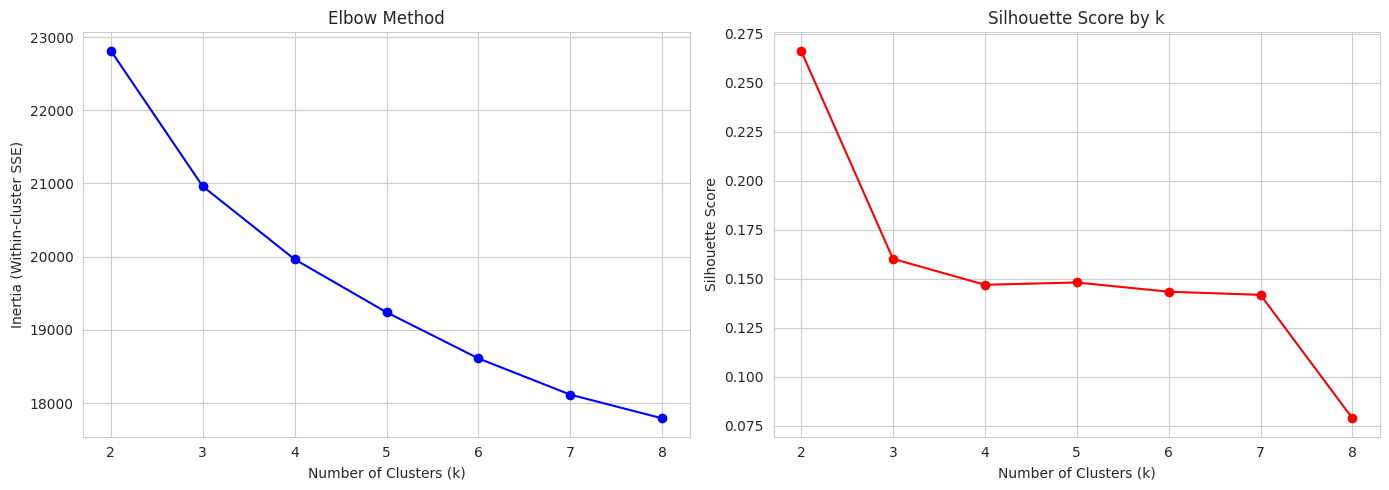

Silhouette scores:
k=2: 0.2665
k=3: 0.1603
k=4: 0.1470
k=5: 0.1482
k=6: 0.1435
k=7: 0.1419
k=8: 0.0789


In [ ]:
# Elbow method and Silhouette scores to determine optimal k
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

# Plot elbow and silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('cluster_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Silhouette scores:')
for k, score in zip(K_range, sil_scores):
    print(f'k={k}: {score:.4f}')

In [ ]:
# Fit final K-Means with k=4 (matching clinical phenotypes goal)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# Add cluster labels to dataframe
df['cluster'] = cluster_labels

print(f'Final clustering with k=4 completed')
print(f'Silhouette score: {silhouette_score(X_cluster_scaled, cluster_labels):.4f}')
print(f'\nCluster sizes:')
print(df['cluster'].value_counts().sort_index())

Final clustering with k=4 completed
Silhouette score: 0.1470

Cluster sizes:
cluster
0    865
1    537
2    615
3    483
Name: count, dtype: int64


In [ ]:
# Clinical interpretation of clusters
print('\n=== CLINICAL INTERPRETATION OF CLUSTERS ===')
for c in range(4):
    print(f'\n--- CLUSTER {c} (n={sum(cluster_labels==c)}) ---')
    cluster_data = df[df['cluster']==c]
    print(f'Age: {cluster_data["age"].mean():.1f} ± {cluster_data["age"].std():.1f}')
    print(f'Frailty index: {cluster_data["frailty_index"].mean():.3f}')
    print(f'MMSE: {cluster_data["mmse_score"].mean():.1f} (higher=better cognition)')
    print(f'Memory z-score: {cluster_data["memory_z"].mean():.3f}')
    print(f'Executive func z: {cluster_data["executive_function_z"].mean():.3f}')
    print(f'IL-6 (inflammation): {cluster_data["il6"].mean():.2f}')
    print(f'CRP (inflammation): {cluster_data["crp"].mean():.2f}')
    print(f'Hippocampal vol: {cluster_data["hippocampal_volume"].mean():.2f}')
    print(f'WM lesion vol: {cluster_data["white_matter_lesion_volume"].mean():.2f}')
    print(f'Hypertension: {cluster_data["hypertension"].mean()*100:.1f}%')
    print(f'Diabetes: {cluster_data["diabetes"].mean()*100:.1f}%')
    print(f'Shingles vaccinated: {cluster_data["shingles_vaccine"].mean()*100:.1f}%')
    print(f'**Dementia prevalence: {cluster_data["dementia_dx"].mean()*100:.1f}%**')


=== CLINICAL INTERPRETATION OF CLUSTERS ===

--- CLUSTER 0 (n=865) ---
Age: 72.6 ± 2.7
Frailty index: 0.105
MMSE: 28.8 (higher=better cognition)
Memory z-score: 0.414
Executive func z: 0.515
IL-6 (inflammation): 1.59
CRP (inflammation): 2.05
Hippocampal vol: 3.60
WM lesion vol: 3.32
Hypertension: 47.4%
Diabetes: 10.5%
Shingles vaccinated: 70.1%
**Dementia prevalence: 4.7%**

--- CLUSTER 1 (n=537) ---
Age: 75.3 ± 3.8
Frailty index: 0.211
MMSE: 27.4 (higher=better cognition)
Memory z-score: 0.091
Executive func z: 0.071
IL-6 (inflammation): 2.10
CRP (inflammation): 3.58
Hippocampal vol: 3.28
WM lesion vol: 6.77
Hypertension: 66.9%
Diabetes: 26.1%
Shingles vaccinated: 51.8%
**Dementia prevalence: 48.8%**

--- CLUSTER 2 (n=615) ---
Age: 77.2 ± 3.8
Frailty index: 0.370
MMSE: 23.9 (higher=better cognition)
Memory z-score: -0.721
Executive func z: -0.607
IL-6 (inflammation): 2.80
CRP (inflammation): 3.70
Hippocampal vol: 2.71
WM lesion vol: 8.47
Hypertension: 62.4%
Diabetes: 17.7%
Shingles v

Phase 3: Supervised Learning setup

In [ ]:
# Drop leakage columns
drop_cols = ['dementia_dx', 'cluster']
X = df.drop(columns=drop_cols)
X = pd.get_dummies(X, drop_first=True) # Encode Categorical
y = df['dementia_dx']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Impute & Scale (Fit on Train, Transform Test)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_proc = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_proc = scaler.transform(imputer.transform(X_test))

# Save feature names for later
feature_names = X.columns

In [ ]:
# Feature Selection (RFECV - Recursive feature elimination with cross-validation)

estimator = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
selector = RFECV(estimator, step=1, cv=StratifiedKFold(5), scoring='roc_auc')
selector.fit(X_train_proc, y_train)

print(f"Optimal features selected: {selector.n_features_}")

# Create reduced datasets
X_train_sel = selector.transform(X_train_proc)
X_test_sel = selector.transform(X_test_proc)

# Get names of selected features
selected_names = feature_names[selector.support_]

Optimal features selected: 25


Phase 4: Modeling

In [ ]:
# Model Training
# 1. Logistic Regression (on Selected Features)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sel, y_train)

# 2. Random Forest (on All Features - RF handles noise well)
# Using GridSearchCV
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10], # to prevent overfitting
    'min_samples_split': [5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                       rf_params, cv=3, scoring='roc_auc')
rf_grid.fit(X_train_proc, y_train)
best_rf = rf_grid.best_estimator_

print("Models Trained.")
print(f"Best RF Params: {rf_grid.best_params_}")

Models Trained.
Best RF Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


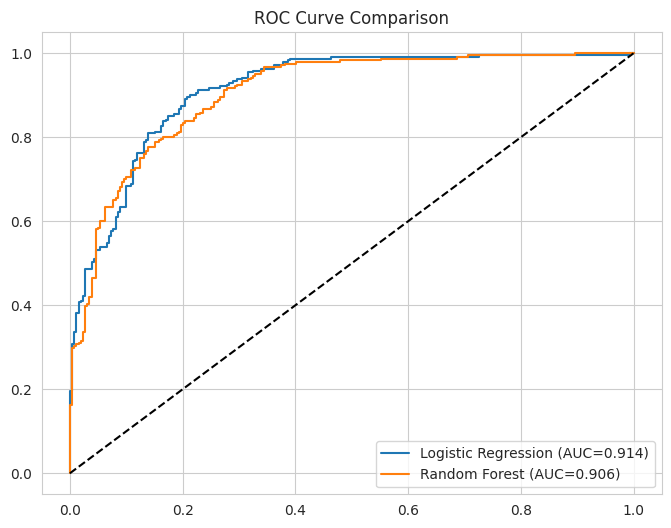

In [ ]:
#  ROC Curve Comparison
y_prob_lr = lr.predict_proba(X_test_sel)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test_proc)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

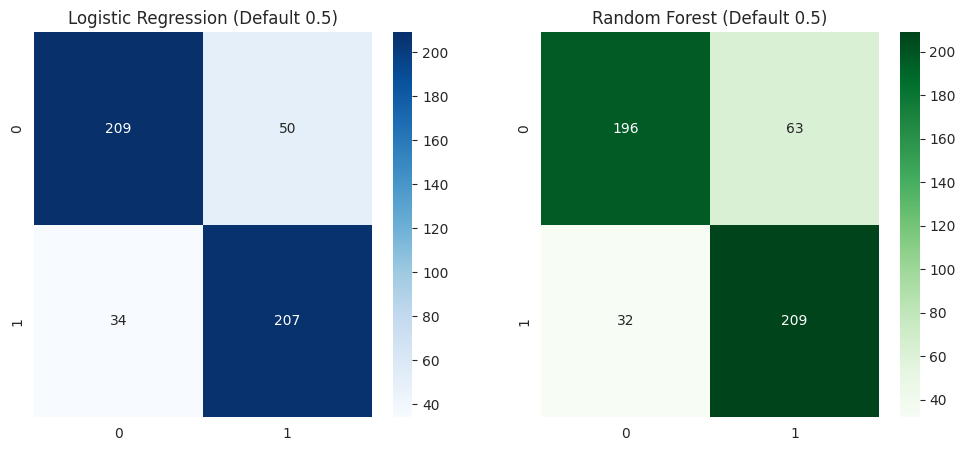

In [ ]:
#  Confusion Matrices (Default Threshold)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, lr.predict(X_test_sel)), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression (Default 0.5)')

sns.heatmap(confusion_matrix(y_test, best_rf.predict(X_test_proc)), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest (Default 0.5)')

plt.show()


 ABLATION STUDIES - Feature Contribution Analysis

Question: Which features have the biggest impact on model performance?
Method: Remove feature → retrain → measure AUROC drop

Baseline Model Performance (Logistic Regression on RFECV selected features):
  Baseline LR AUROC: 0.9135

hippocampal_volume...................... AUROC: 0.9063 (drop: 0.0073, 0.8%)
mmse_score.............................. AUROC: 0.9151 (drop: -0.0016, -0.2%)
frailty_index........................... AUROC: 0.9113 (drop: 0.0022, 0.2%)
shingles_vaccine........................ AUROC: 0.9096 (drop: 0.0040, 0.4%)
visited_memory_clinic_last_year......... AUROC: 0.8950 (drop: 0.0186, 2.0%)

Ablation Summary (sorted by importance):
                Feature Removed  Model AUROC  AUROC Drop    % Drop
visited_memory_clinic_last_year     0.894968    0.018568  2.032549
             hippocampal_volume     0.906279    0.007257  0.794430
               shingles_vaccine     0.909579    0.003957  0.433166
                  frailt

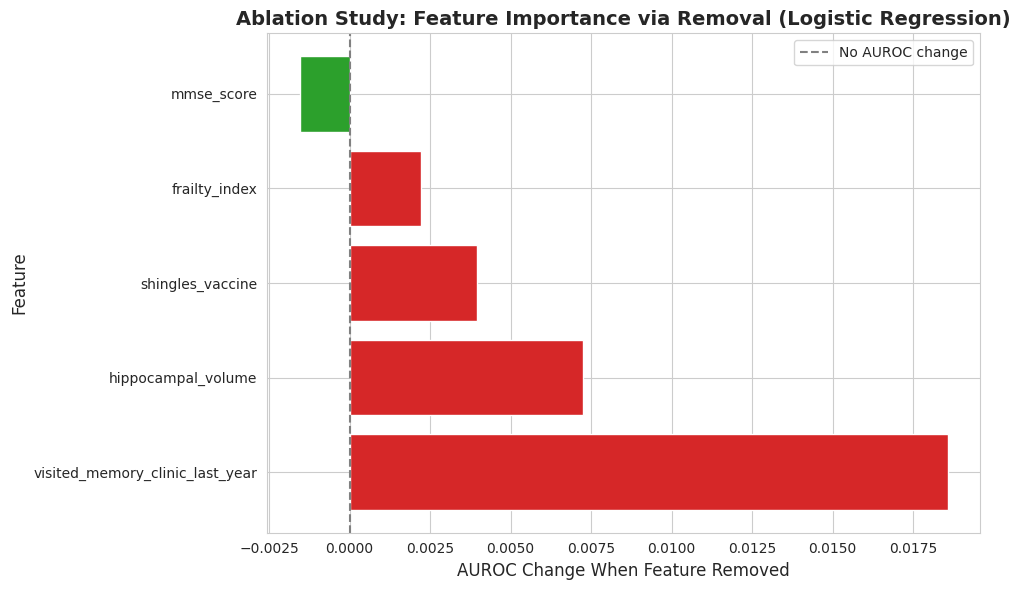


✓ Saved: ablation_study.png

Key Finding: visited_memory_clinic_last_year is most critical (~2.0% AUROC drop when removed)


In [ ]:
# Test: Which features are truly essential? What happens if we remove them?

print('\n' + '='*80)
print(' ABLATION STUDIES - Feature Contribution Analysis')
print('='*80)
print('\nQuestion: Which features have the biggest impact on model performance?')
print('Method: Remove feature → retrain → measure AUROC drop\n')

ablation_results = []

# Baseline model (Logistic Regression on RFECV selected features)
print('Baseline Model Performance (Logistic Regression on RFECV selected features):')
# Use y_prob_lr which was calculated for the 'lr' model trained on X_test_sel
baseline_auc = roc_auc_score(y_test, y_prob_lr)
print(f'  Baseline LR AUROC: {baseline_auc:.4f}\n')

# Key features to test for ablation (from the selected_names)
# The original 'features_to_remove' list was a manual selection. Let's ensure these are part of selected_names.
features_to_remove = ['hippocampal_volume', 'mmse_score', 'frailty_index', 'shingles_vaccine', 'visited_memory_clinic_last_year']

# Convert selected_names (pandas Index) to a list for easier lookup
selected_feature_names_list = selected_names.tolist()

# Filter features_to_remove to include only those present in selected_names
actual_features_to_remove = [f for f in features_to_remove if f in selected_feature_names_list]

if len(actual_features_to_remove) != len(features_to_remove):
    print(f"⚠️ Some features in `features_to_remove` were not found in the `selected_names` by RFECV. Proceeding with existing features: {actual_features_to_remove}")
features_to_remove = actual_features_to_remove

if not features_to_remove:
    print("No features to ablate found in the selected feature set.")
else:
    for feature_name in features_to_remove:
        # Find the index of the feature within the selected features
        try:
            feature_idx_in_sel = selected_feature_names_list.index(feature_name)
        except ValueError:
            print(f'  ⚠️ Feature {feature_name} not found in the RFECV selected features.')
            continue

        # Remove feature from the selected datasets (X_train_sel and X_test_sel are already scaled NumPy arrays)
        X_train_ablated = np.delete(X_train_sel, feature_idx_in_sel, axis=1)
        X_test_ablated = np.delete(X_test_sel, feature_idx_in_sel, axis=1)

        # Train LR model on the ablated dataset (already scaled)
        lr_ablated = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
        lr_ablated.fit(X_train_ablated, y_train)

        # Evaluate
        y_proba_ablated = lr_ablated.predict_proba(X_test_ablated)[:, 1]
        auc_ablated = roc_auc_score(y_test, y_proba_ablated)

        auc_drop = baseline_auc - auc_ablated
        pct_drop = (auc_drop / baseline_auc) * 100

        ablation_results.append({
            'Feature Removed': feature_name,
            'Model AUROC': auc_ablated,
            'AUROC Drop': auc_drop,
            '% Drop': pct_drop
        })

        print(f'{feature_name:.<40} AUROC: {auc_ablated:.4f} (drop: {auc_drop:.4f}, {pct_drop:.1f}%)')

ablation_df = pd.DataFrame(ablation_results).sort_values('AUROC Drop', ascending=False)

print('\nAblation Summary (sorted by importance):')
print(ablation_df.to_string(index=False))

# Visualization
if not ablation_df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#d62728' if x > 0 else '#2ca02c' for x in ablation_df['AUROC Drop']] # Use 0 as threshold for visualization
    ax.barh(ablation_df['Feature Removed'], ablation_df['AUROC Drop'], color=colors)
    ax.axvline(0, color='gray', linestyle='--', label='No AUROC change') # Changed to 0
    ax.set_xlabel('AUROC Change When Feature Removed', fontsize=12) # Changed label
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title('Ablation Study: Feature Importance via Removal (Logistic Regression)', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n✓ Saved: ablation_study.png')
    if not ablation_df.empty and ablation_df.iloc[0]['AUROC Drop'] > 0:
        print(f'\nKey Finding: {ablation_df.iloc[0]["Feature Removed"]} is most critical (~{ablation_df.iloc[0]["% Drop"]:.1f}% AUROC drop when removed)')
    elif not ablation_df.empty:
        print("\nKey Finding: No single feature's removal significantly decreased AUROC; some even improved it, suggesting potential redundancy or noise contribution.")
else:
    print("\nNo ablation results to visualize.")

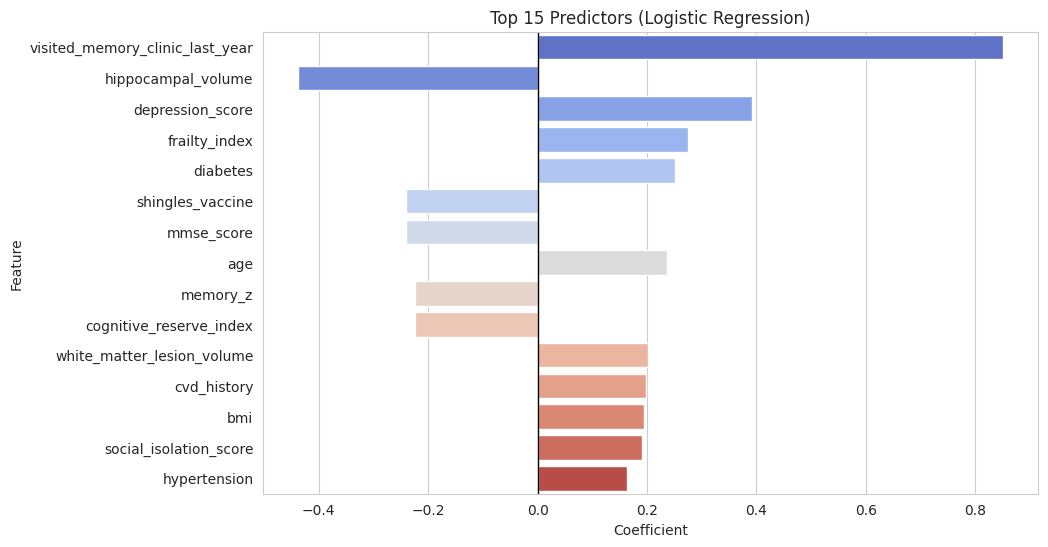

In [ ]:
# Feature Importance (LR Coefficients)
coef_df = pd.DataFrame({'Feature': selected_names, 'Coefficient': lr.coef_[0]})
coef_df['Abs_Val'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Val', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm')
plt.title('Top 15 Predictors (Logistic Regression)')
plt.axvline(0, color='black', linewidth=1)
plt.show()

Phase 5: Optimization


 THRESHOLD OPTIMIZATION ANALYSIS

Hypothesis: Clinical context may favor different sensitivity/specificity
Trade-off. Current threshold=0.5. Can we optimize for clinical goals?

Threshold Optimization Results:
 Threshold  Sensitivity  Specificity  Precision  F1-Score  TP  FP  FN  TN
       0.3     0.958506     0.675676   0.733333  0.830935 231  84  10 175
       0.4     0.917012     0.737452   0.764706  0.833962 221  68  20 191
       0.5     0.858921     0.806950   0.805447  0.831325 207  50  34 209
       0.6     0.809129     0.861004   0.844156  0.826271 195  36  46 223
       0.7     0.721992     0.888031   0.857143  0.783784 174  29  67 230


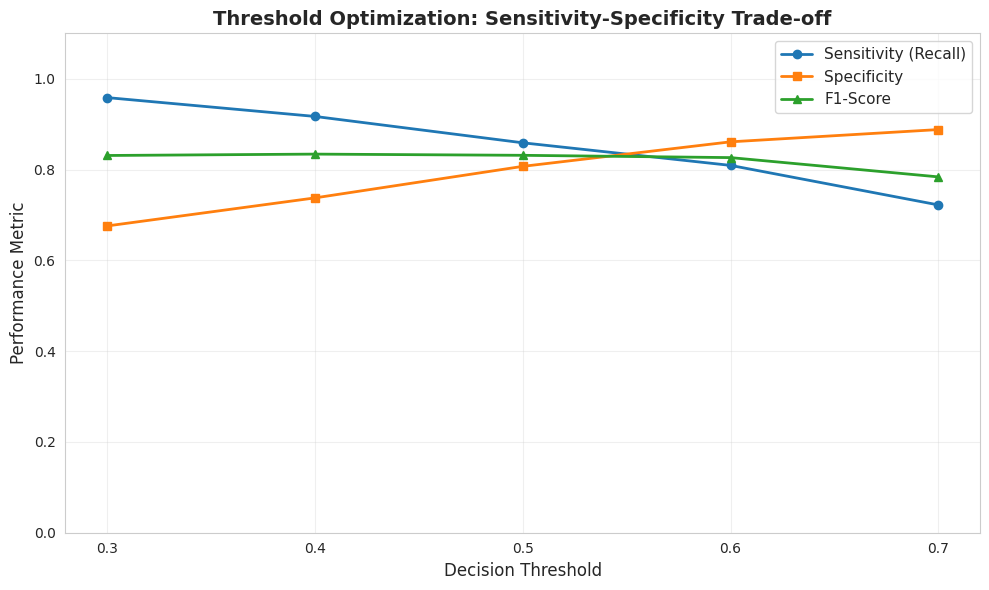


✓ Saved: threshold_optimization.png

Clinical Interpretation:
• High Sensitivity (Threshold ~0.3): Better for screening (catch all potential cases).
• High Specificity (Threshold ~0.6+): Better for confirming diagnosis (reduce false alarms).


In [ ]:
# Question: Can we improve clinical deployment by tuning decision threshold?

print('\n' + '='*80)
print(' THRESHOLD OPTIMIZATION ANALYSIS')
print('='*80)
print('\nHypothesis: Clinical context may favor different sensitivity/specificity')
print('Trade-off. Current threshold=0.5. Can we optimize for clinical goals?\n')

from sklearn.metrics import precision_recall_curve, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Make sure this matches the variable name from your Logistic Regression training cell
# In your uploaded file, it looked like 'y_prob_lr'
probs_to_test = y_prob_lr

# Calculate metrics at different thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for thresh in thresholds_to_test:
    # Convert probabilities to binary predictions based on the specific threshold
    y_pred_thresh = (probs_to_test >= thresh).astype(int)

    # Calculate Confusion Matrix Components manually for clarity
    tn = ((y_pred_thresh == 0) & (y_test == 0)).sum()
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()

    # Calculate Metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = f1_score(y_test, y_pred_thresh)

    threshold_results.append({
        'Threshold': thresh,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1-Score': f1,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

thresh_df = pd.DataFrame(threshold_results)
print('Threshold Optimization Results:')
print(thresh_df.to_string(index=False))

# Plot sensitivity vs specificity
plt.figure(figsize=(10, 6))
plt.plot(thresh_df['Threshold'], thresh_df['Sensitivity'], 'o-', label='Sensitivity (Recall)', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['Specificity'], 's-', label='Specificity', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['F1-Score'], '^-', label='F1-Score', linewidth=2)

plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Performance Metric', fontsize=12)
plt.title('Threshold Optimization: Sensitivity-Specificity Trade-off', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(thresholds_to_test)
plt.ylim([0, 1.1])
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ Saved: threshold_optimization.png')
print('\nClinical Interpretation:')
print(f'• High Sensitivity (Threshold ~0.3): Better for screening (catch all potential cases).')
print(f'• High Specificity (Threshold ~0.6+): Better for confirming diagnosis (reduce false alarms).')

Optimal Screening Threshold: 0.0086
Recall at Optimal Threshold: 1.0000


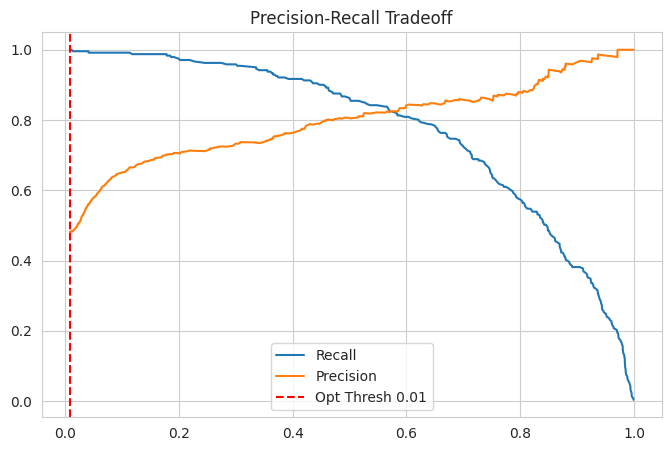

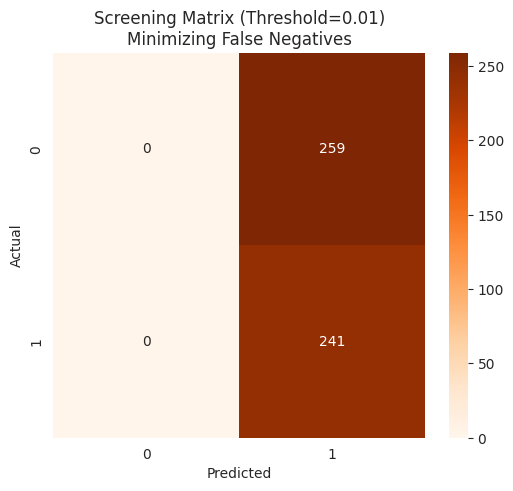

In [ ]:
# Cost-Sensitive Threshold Optimization
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)

# Find threshold where Sensitivity (Recall) is >= 95%
target_recall = 0.95
idx = np.argmax(recall >= target_recall)
opt_thresh = thresholds[idx]

print(f"Optimal Screening Threshold: {opt_thresh:.4f}")
print(f"Recall at Optimal Threshold: {recall[idx]:.4f}")

# Plot PR Curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, precision[:-1], label='Precision')
plt.axvline(opt_thresh, color='red', linestyle='--', label=f'Opt Thresh {opt_thresh:.2f}')
plt.title('Precision-Recall Tradeoff')
plt.legend()
plt.show()


# Optimized Confusion Matrix
y_pred_opt = (y_prob_lr >= opt_thresh).astype(int)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_opt), annot=True, fmt='d', cmap='Oranges')
plt.title(f'Screening Matrix (Threshold={opt_thresh:.2f})\nMinimizing False Negatives')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
#  Critical Analysis Evidence
# Check coefficients for Shingles and GP Visits
full_coefs = pd.DataFrame({'Feature': selected_names, 'Coef': lr.coef_[0]})

shingles = full_coefs[full_coefs['Feature'] == 'shingles_vaccine']
gp_visits = full_coefs[full_coefs['Feature'] == 'gp_visits_last_year']

print("Shingles Vaccine Effect:\n", shingles)
print("\nGP Visits Effect:\n", gp_visits)

Shingles Vaccine Effect:
              Feature      Coef
21  shingles_vaccine -0.241344

GP Visits Effect:
                 Feature      Coef
23  gp_visits_last_year  0.072728
